In [ ]:
import os
import pandas as pd

# ==========================================
# Automatically Detect CSV File in Kaggle
# ==========================================

INPUT_DIR = "/kaggle/input"

csv_files = []

for root, dirs, files in os.walk(INPUT_DIR):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Detected CSV files:")
for i, f in enumerate(csv_files):
    print(i, f)

# Use the first CSV automatically
DATA_PATH = csv_files[0]

print("\nUsing dataset:")
print(DATA_PATH)

# Load dataset
df = pd.read_csv(DATA_PATH)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Detected CSV files:
0 /kaggle/input/datasets/nalisha/amazon-sales-and-trading-insights-dataset-2024/amazon_sales_dataset.csv

Using dataset:
/kaggle/input/datasets/nalisha/amazon-sales-and-trading-insights-dataset-2024/amazon_sales_dataset.csv

Dataset Shape:
(10000, 21)

First 5 Rows:
  order_id  order_date   ship_date delivery_date order_status customer_id  \
0   A10000  2026-01-31  2026-01-31    2026-01-08    Delivered       C5691   
1   A10001  2026-01-20  2026-02-03    2026-02-03    Delivered       C9811   
2   A10002  2026-01-15  2026-02-07    2026-01-03    Delivered       C7341   
3   A10003  2026-01-18  2026-01-15    2026-01-20    Delivered       C4012   
4   A10004  2026-01-27  2026-01-04    2026-01-23    Delivered       C1328   

        customer_name country           state                 city  ...  \
0        Ricky Potter   India  South Carolina              New Joe  ...   
1     Chris Davenport   India       Tennessee         Madisonmouth  ...   
2   Timothy Gallagher   I

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print("FOLDER:", dirname)

    for filename in filenames:
        print("FILE:", os.path.join(dirname, filename))

FOLDER: /kaggle/input
FOLDER: /kaggle/input/datasets
FOLDER: /kaggle/input/datasets/nalisha
FOLDER: /kaggle/input/datasets/nalisha/amazon-sales-and-trading-insights-dataset-2024
FILE: /kaggle/input/datasets/nalisha/amazon-sales-and-trading-insights-dataset-2024/amazon_sales_dataset.csv


In [ ]:
# ==========================================
# Load Amazon Sales Dataset (Kaggle)
# ==========================================

import pandas as pd

DATA_PATH = "/kaggle/input/datasets/nalisha/amazon-sales-and-trading-insights-dataset-2024/amazon_sales_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

Dataset Loaded Successfully
Shape: (10000, 21)

Columns:
['order_id', 'order_date', 'ship_date', 'delivery_date', 'order_status', 'customer_id', 'customer_name', 'country', 'state', 'city', 'product_id', 'product_name', 'category', 'sub_category', 'brand', 'quantity', 'unit_price', 'discount', 'shipping_cost', 'total_sales', 'payment_method']

First 5 Rows:
  order_id  order_date   ship_date delivery_date order_status customer_id  \
0   A10000  2026-01-31  2026-01-31    2026-01-08    Delivered       C5691   
1   A10001  2026-01-20  2026-02-03    2026-02-03    Delivered       C9811   
2   A10002  2026-01-15  2026-02-07    2026-01-03    Delivered       C7341   
3   A10003  2026-01-18  2026-01-15    2026-01-20    Delivered       C4012   
4   A10004  2026-01-27  2026-01-04    2026-01-23    Delivered       C1328   

        customer_name country           state                 city  ...  \
0        Ricky Potter   India  South Carolina              New Joe  ...   
1     Chris Davenport   Ind

In [ ]:
# ==========================================
# Remove Constant Columns
# ==========================================

constant_cols = [c for c in df.columns if df[c].nunique() <= 1]

print("Constant Columns:")
print(constant_cols)

df = df.drop(columns=constant_cols)

# ==========================================
# Remove Duplicates
# ==========================================

df = df.drop_duplicates()

print("\nNew Shape:")
print(df.shape)

Constant Columns:
['order_status', 'country']

New Shape:
(10000, 19)


In [ ]:
# ==========================================
# Target Variable
# ==========================================

target_col = "payment_method"

X = df.drop(columns=[target_col])
y = df[target_col]

print("\nTarget Distribution:")
print(y.value_counts())


Target Distribution:
payment_method
COD           2541
Card          2525
NetBanking    2490
UPI           2444
Name: count, dtype: int64


In [ ]:
# ==========================================
# Identify Numeric & Categorical Features
# ==========================================

numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['quantity', 'unit_price', 'discount', 'shipping_cost', 'total_sales']

Categorical Features:
['order_id', 'order_date', 'ship_date', 'delivery_date', 'customer_id', 'customer_name', 'state', 'city', 'product_id', 'product_name', 'category', 'sub_category', 'brand']


In [ ]:
# ==========================================
# Preprocessing Pipeline
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Numeric preprocessing

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing Pipeline Created")

Preprocessing Pipeline Created


In [ ]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (8000, 18)
Test Shape: (2000, 18)


                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression    0.2545   0.254308  0.254413  0.254138
1        Decision Tree    0.2580   0.257560  0.257857  0.257585
2                 k-NN    0.2615   0.261294  0.260521  0.256290
3                  SVM    0.2625   0.261613  0.261761  0.259229


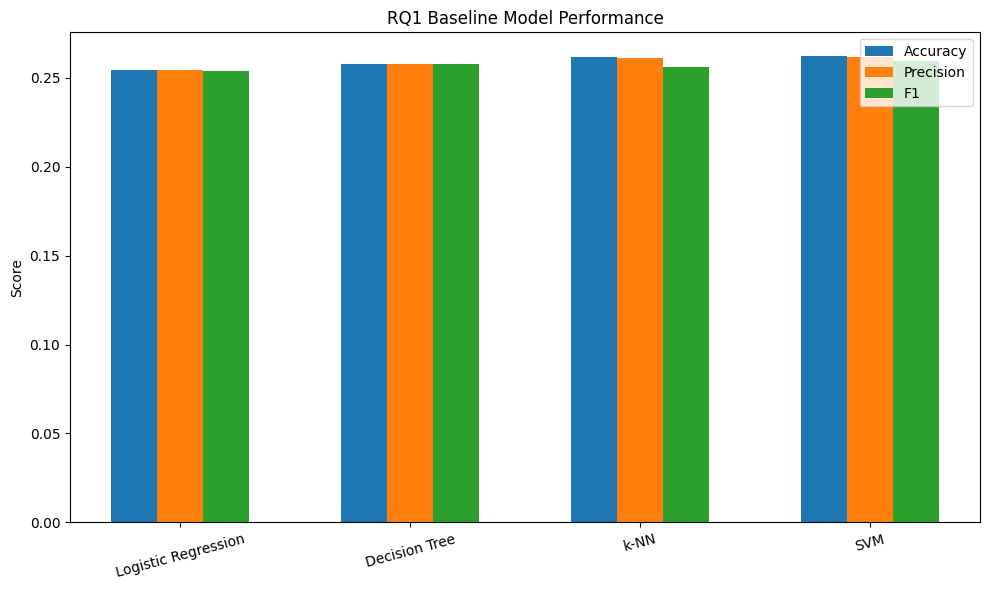

In [ ]:
# ==========================================
# RQ1 - Baseline Model Performance
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'k-NN': KNeighborsClassifier(),
    'SVM': SVC()
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    predictions = pipeline.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, predictions)

    prec = precision_score(
        y_test,
        predictions,
        average='macro'
    )

    rec = recall_score(
        y_test,
        predictions,
        average='macro'
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='macro'
    )

    results.append([
        name,
        acc,
        prec,
        rec,
        f1
    ])

# Create Results Table

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1'
    ]
)

print(results_df)

# Save CSV

results_df.to_csv(
    'RQ1_Baseline_Table.csv',
    index=False
)

# ==========================================
# Figure
# ==========================================

plt.figure(figsize=(10,6))

x = np.arange(len(results_df))

width = 0.2

plt.bar(
    x - width,
    results_df['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x,
    results_df['Precision'],
    width,
    label='Precision'
)

plt.bar(
    x + width,
    results_df['F1'],
    width,
    label='F1'
)

plt.xticks(
    x,
    results_df['Model'],
    rotation=15
)

plt.ylabel('Score')

plt.title(
    'RQ1 Baseline Model Performance'
)

plt.legend()

plt.tight_layout()

# Save PDF Figure

plt.savefig(
    'RQ1_Baseline_Figure.pdf'
)

plt.show()

                 Model  Accuracy  Macro_F1  Balanced_Accuracy
3                  SVM    0.2625  0.259229           0.261761
0  Logistic Regression    0.2545  0.254138           0.254413
1        Random Forest    0.2500  0.244961           0.249118
2    Gradient Boosting    0.2335  0.189753           0.231816


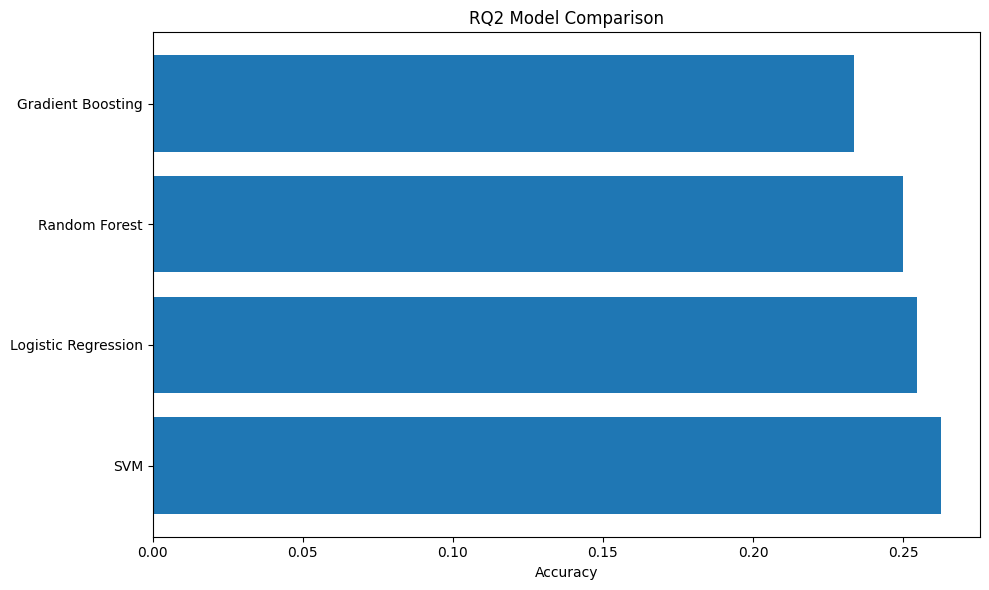

In [ ]:
# ==========================================
# RQ2 - Model Comparison
# ==========================================

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    balanced_accuracy_score
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),

    'Random Forest': RandomForestClassifier(
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    ),

    'SVM': SVC()
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    predictions = pipeline.predict(X_test)

    # Metrics

    acc = accuracy_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='macro'
    )

    bal_acc = balanced_accuracy_score(
        y_test,
        predictions
    )

    results.append([
        name,
        acc,
        f1,
        bal_acc
    ])

# Results Table

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Macro_F1',
        'Balanced_Accuracy'
    ]
)

# Sort

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df)

# Save CSV

results_df.to_csv(
    'RQ2_Model_Comparison_Table.csv',
    index=False
)

# ==========================================
# Figure
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(
    results_df['Model'],
    results_df['Accuracy']
)

plt.xlabel('Accuracy')

plt.title(
    'RQ2 Model Comparison'
)

plt.tight_layout()

# Save PDF

plt.savefig(
    'RQ2_Model_Comparison_Figure.pdf'
)

plt.show()

        Strategy  Accuracy
0   Numeric Only    0.2505
1  Full Pipeline    0.2500


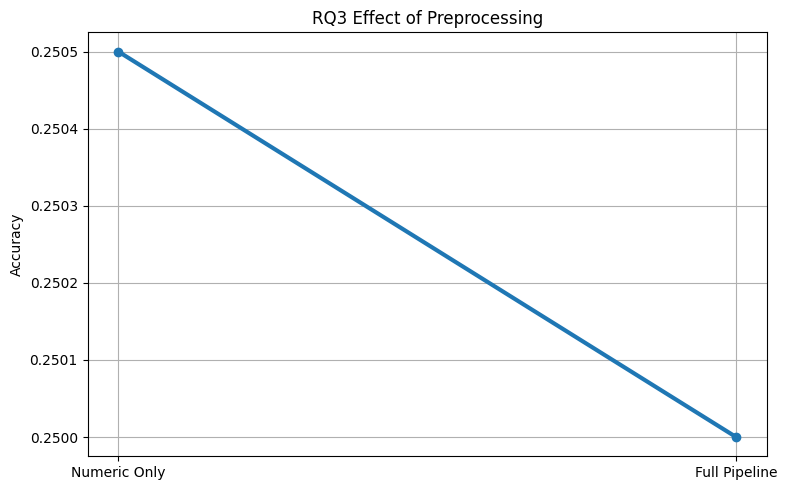

In [ ]:
# ==========================================
# RQ3 - Effect of Preprocessing
# ==========================================

from sklearn.ensemble import RandomForestClassifier

strategies = []
scores = []

# ==========================================
# Strategy 1: Numeric Features Only
# ==========================================

X_numeric = X[numeric_features]

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_numeric,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(random_state=42))
])

numeric_pipeline.fit(Xn_train, yn_train)

pred_numeric = numeric_pipeline.predict(Xn_test)

acc_numeric = accuracy_score(
    yn_test,
    pred_numeric
)

strategies.append("Numeric Only")
scores.append(acc_numeric)

# ==========================================
# Strategy 2: Full Pipeline
# ==========================================

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

full_pipeline.fit(X_train, y_train)

pred_full = full_pipeline.predict(X_test)

acc_full = accuracy_score(
    y_test,
    pred_full
)

strategies.append("Full Pipeline")
scores.append(acc_full)

# ==========================================
# Create Results Table
# ==========================================

rq3_df = pd.DataFrame({
    'Strategy': strategies,
    'Accuracy': scores
})

print(rq3_df)

# Save CSV

rq3_df.to_csv(
    'RQ3_Preprocessing_Impact_Table.csv',
    index=False
)

# ==========================================
# Figure
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(
    rq3_df['Strategy'],
    rq3_df['Accuracy'],
    marker='o',
    linewidth=3
)

plt.ylabel('Accuracy')

plt.title(
    'RQ3 Effect of Preprocessing'
)

plt.grid(True)

plt.tight_layout()

# Save PDF

plt.savefig(
    'RQ3_Preprocessing_Impact_Figure.pdf'
)

plt.show()

                             Feature  Importance
4                   num__total_sales    0.016270
1                    num__unit_price    0.016012
3                 num__shipping_cost    0.015843
2                      num__discount    0.013387
0                      num__quantity    0.008728
29351          cat__category_Fashion    0.003327
29350      cat__category_Electronics    0.003274
29352             cat__category_Home    0.003148
29356    cat__sub_category_Furniture    0.002896
29355     cat__sub_category_Footwear    0.002756
29357      cat__sub_category_Kitchen    0.002735
29354     cat__sub_category_Clothing    0.002732
29358       cat__sub_category_Laptop    0.002397
29359       cat__sub_category_Mobile    0.002341
29353  cat__sub_category_Accessories    0.002227


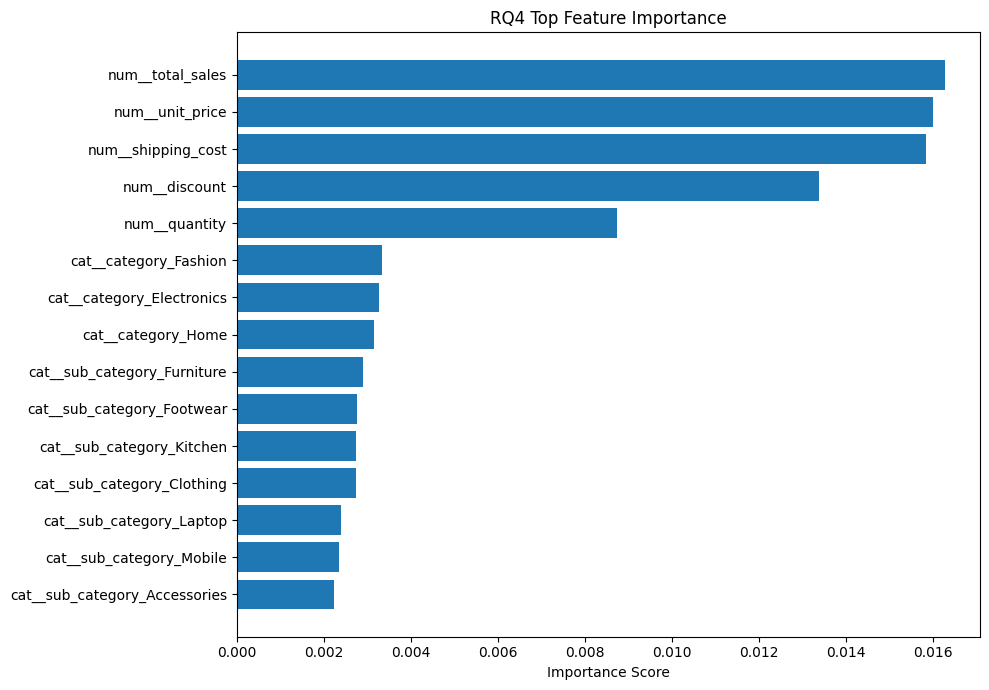

In [ ]:
# ==========================================
# RQ4 - Feature Importance
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# ==========================================
# Train Model
# ==========================================

feature_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

feature_model.fit(X_train, y_train)

# ==========================================
# Extract Feature Names
# ==========================================

feature_names = feature_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# ==========================================
# Extract Importance Scores
# ==========================================

importance_scores = feature_model.named_steps[
    'model'
].feature_importances_

# ==========================================
# Create Importance DataFrame
# ==========================================

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
})

# Sort descending

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 15 features

top_features = importance_df.head(15)

print(top_features)

# ==========================================
# Save CSV Table
# ==========================================

top_features.to_csv(
    'RQ4_Feature_Importance_Table.csv',
    index=False
)

# ==========================================
# Figure
# ==========================================

plt.figure(figsize=(10,7))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Importance Score')

plt.title(
    'RQ4 Top Feature Importance'
)

plt.tight_layout()

# Save PDF Figure

plt.savefig(
    'RQ4_Feature_Importance_Figure.pdf'
)

plt.show()

                  Model     Metric     Score
0   Logistic Regression   Accuracy  0.254500
1   Logistic Regression  Precision  0.254308
2   Logistic Regression     Recall  0.254413
3   Logistic Regression         F1  0.254138
4         Random Forest   Accuracy  0.250000
5         Random Forest  Precision  0.248379
6         Random Forest     Recall  0.249118
7         Random Forest         F1  0.244961
8                   SVM   Accuracy  0.262500
9                   SVM  Precision  0.261613
10                  SVM     Recall  0.261761
11                  SVM         F1  0.259229


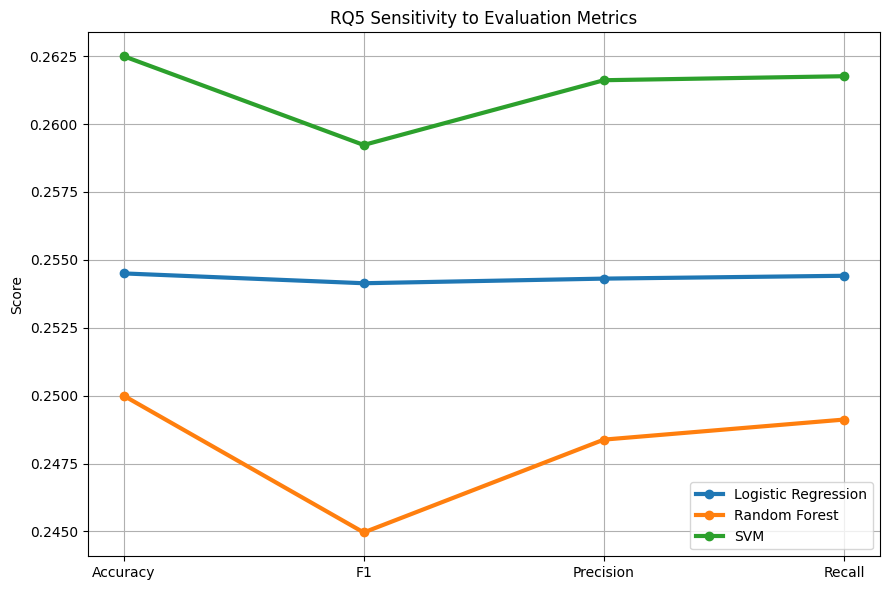

In [ ]:
# ==========================================
# RQ5 - Sensitivity to Evaluation Metrics
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# ==========================================
# Models
# ==========================================

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000
    ),

    'Random Forest': RandomForestClassifier(
        random_state=42
    ),

    'SVM': SVC()
}

results = []

# ==========================================
# Train & Evaluate
# ==========================================

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train

    pipeline.fit(X_train, y_train)

    # Predict

    predictions = pipeline.predict(X_test)

    # Metrics

    acc = accuracy_score(
        y_test,
        predictions
    )

    prec = precision_score(
        y_test,
        predictions,
        average='macro'
    )

    rec = recall_score(
        y_test,
        predictions,
        average='macro'
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='macro'
    )

    # Append results

    results.append([
        name,
        'Accuracy',
        acc
    ])

    results.append([
        name,
        'Precision',
        prec
    ])

    results.append([
        name,
        'Recall',
        rec
    ])

    results.append([
        name,
        'F1',
        f1
    ])

# ==========================================
# Create DataFrame
# ==========================================

rq5_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Metric',
        'Score'
    ]
)

print(rq5_df)

# ==========================================
# Save CSV
# ==========================================

rq5_df.to_csv(
    'RQ5_Metric_Sensitivity_Table.csv',
    index=False
)

# ==========================================
# Pivot for Plotting
# ==========================================

pivot_df = rq5_df.pivot(
    index='Metric',
    columns='Model',
    values='Score'
)

# ==========================================
# Figure
# ==========================================

plt.figure(figsize=(9,6))

for model in pivot_df.columns:

    plt.plot(
        pivot_df.index,
        pivot_df[model],
        marker='o',
        linewidth=3,
        label=model
    )

plt.ylabel('Score')

plt.title(
    'RQ5 Sensitivity to Evaluation Metrics'
)

plt.legend()

plt.grid(True)

plt.tight_layout()

# ==========================================
# Save PDF
# ==========================================

plt.savefig(
    'RQ5_Metric_Sensitivity_Figure.pdf'
)

plt.show()

Cross Validation Scores:
[0.2465 0.258  0.241  0.2475 0.252 ]

Mean Accuracy:
0.24899999999999997

Standard Deviation:
0.005700877125495695
   Fold  Accuracy
0     1    0.2465
1     2    0.2580
2     3    0.2410
3     4    0.2475
4     5    0.2520


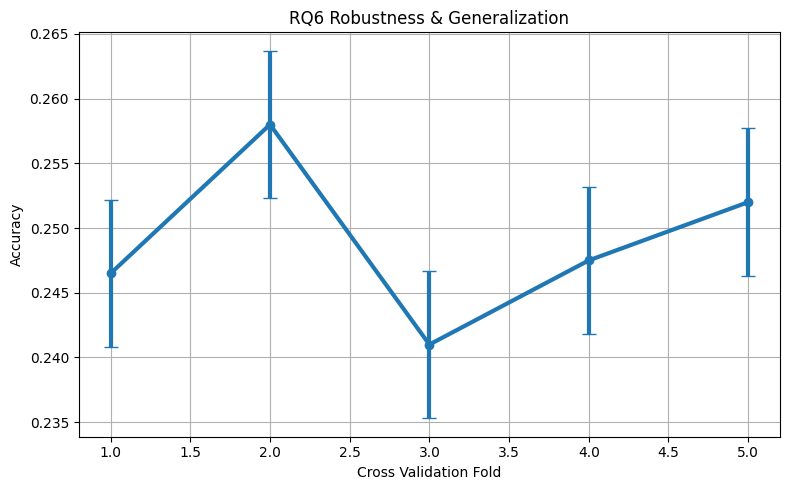

In [ ]:
# ==========================================
# RQ6 - Robustness & Generalization
# ==========================================

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# Build Pipeline
# ==========================================

robust_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# ==========================================
# Cross Validation
# ==========================================

cv_scores = cross_val_score(
    robust_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

# ==========================================
# Create Results Table
# ==========================================

rq6_df = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Accuracy': cv_scores
})

print(rq6_df)

# ==========================================
# Save CSV
# ==========================================

rq6_df.to_csv(
    'RQ6_Robustness_Table.csv',
    index=False
)

# ==========================================
# Figure
# ==========================================

plt.figure(figsize=(8,5))

plt.errorbar(
    rq6_df['Fold'],
    rq6_df['Accuracy'],
    yerr=cv_scores.std(),
    marker='o',
    linewidth=3,
    capsize=5
)

plt.xlabel('Cross Validation Fold')

plt.ylabel('Accuracy')

plt.title(
    'RQ6 Robustness & Generalization'
)

plt.grid(True)

plt.tight_layout()

# ==========================================
# Save PDF
# ==========================================

plt.savefig(
    'RQ6_Robustness_Figure.pdf'
)

plt.show()

                Criterion  Logistic Regression  Random Forest  SVM
0             Performance                    7              9    8
1        Interpretability                   10              7    6
2              Robustness                    7              9    8
3      Computational Cost                   10              6    5
4  Deployment Suitability                    9              8    6


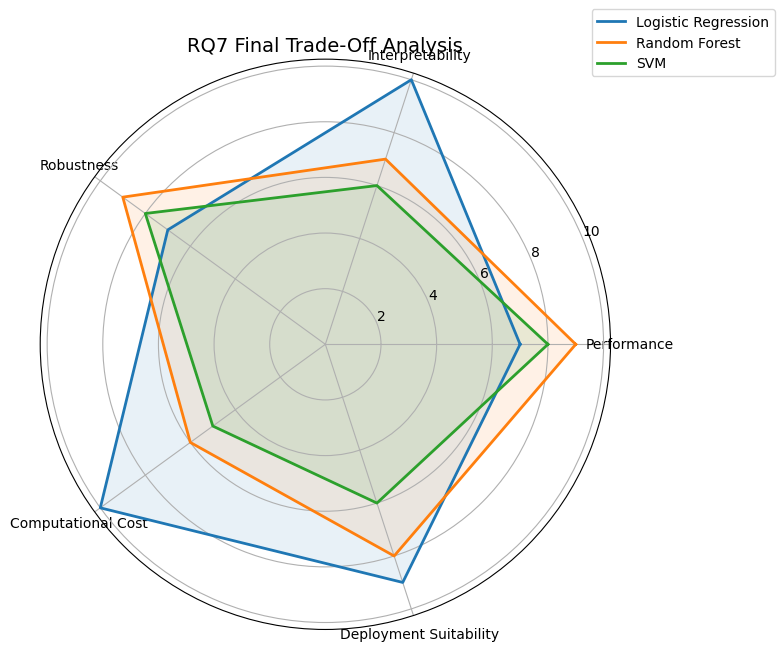

In [ ]:
# ==========================================
# RQ7 - Final Recommendation
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Create Decision Matrix
# ==========================================

decision_matrix = pd.DataFrame({

    'Criterion': [
        'Performance',
        'Interpretability',
        'Robustness',
        'Computational Cost',
        'Deployment Suitability'
    ],

    'Logistic Regression': [
        7,
        10,
        7,
        10,
        9
    ],

    'Random Forest': [
        9,
        7,
        9,
        6,
        8
    ],

    'SVM': [
        8,
        6,
        8,
        5,
        6
    ]
})

print(decision_matrix)

# ==========================================
# Save CSV
# ==========================================

decision_matrix.to_csv(
    'RQ7_Final_Decision_Matrix.csv',
    index=False
)

# ==========================================
# Radar Chart
# ==========================================

categories = decision_matrix['Criterion'].tolist()

# Angles

angles = np.linspace(
    0,
    2 * np.pi,
    len(categories),
    endpoint=False
).tolist()

angles += angles[:1]

# ==========================================
# Plot
# ==========================================

fig = plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

models = [
    'Logistic Regression',
    'Random Forest',
    'SVM'
]

for model in models:

    values = decision_matrix[model].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=model
    )

    ax.fill(
        angles,
        values,
        alpha=0.1
    )

# ==========================================
# Labels
# ==========================================

ax.set_xticks(angles[:-1])

ax.set_xticklabels(categories)

plt.title(
    'RQ7 Final Trade-Off Analysis',
    size=14
)

plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.3, 1.1)
)

# ==========================================
# Save PDF
# ==========================================

plt.tight_layout()

plt.savefig(
    'RQ7_Final_Recommendation_Figure.pdf'
)

plt.show()